In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pickle
import os
from PIL import Image
from matplotlib.pyplot import GridSpec

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [4]:
# get names of all images in dataset_dir/images
image_names = os.listdir(f"{DATASET_DIR}/images")

count_images = len(image_names)

In [5]:
count_images

6659532

In [6]:
# sort image names based on number in name name format is : image_number.png
image_names.sort(key=lambda x: int(x.split(".")[0].split("_")[1]))

In [7]:
image_names[-5:]

['image_6659527.png',
 'image_6659528.png',
 'image_6659529.png',
 'image_6659530.png',
 'image_6659531.png']

In [8]:
label_mapping = {
    'Benign': 'Benign',
    'Bot': 'Botnet',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk': 'DoS',
    'Infilteration': 'Infiltration',
    'Brute Force -Web': 'Brute Force',
    'Brute Force -XSS': 'Brute Force',
    'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
}

data["Label"] = data["Label"].map(label_mapping)

In [9]:
data["Label"].value_counts()

Label
Benign          5329008
DDoS             775955
DoS              196568
Botnet           144535
Infiltration     118568
Brute Force       94898
Name: count, dtype: int64

In [10]:
data.tail()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
6659527,6,19276110,5,10,286,738.0,103,0,57.200001,52.485237,...,20,9667037.0,0.0,9667037.0,9667037.0,9609073.0,0.0,9609073.0,9609073.0,Benign
6659528,6,85992425,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,85992424.0,0.0,85992425.0,85992425.0,Benign
6659529,17,79134,1,1,41,98.0,41,41,41.000000,0.000000,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
6659530,6,10053785,11,12,1321,1659.0,677,0,120.090912,197.116440,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
6659531,6,566835,6,5,455,338.0,140,0,75.833336,62.936211,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [11]:
train_data = data.groupby("Label").sample(5000, random_state=42)
train_data.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1119705,6,4959888,4,4,97,232.0,97,0,24.250000,48.500000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2975672,6,4776917,11,14,1623,4513.0,661,0,147.545456,189.151978,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
6489183,6,1247683,7,5,364,582.0,103,0,52.000000,49.217205,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2675390,6,1098,5,2,935,316.0,935,0,187.000000,418.144714,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
5559062,6,2160480,9,7,1148,1581.0,677,0,127.555557,218.691055,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [12]:
train_data_index = train_data.index
train_data_index

Index([1119705, 2975672, 6489183, 2675390, 5559062, 5463991, 5922107, 6240422,
        402520, 4594508,
       ...
       4609756, 4697052, 4647231, 4968578, 4855172, 4861818, 4964107, 4703193,
       4583200, 4866157],
      dtype='int64', length=30000)

In [13]:
remaining_data = data[~data.index.isin(train_data_index)]
remaining_data.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [14]:
remaining_data["Label"].value_counts()

Label
Benign          5324008
DDoS             770955
DoS              191568
Botnet           139535
Infiltration     113568
Brute Force       89898
Name: count, dtype: int64

In [15]:
# get data for validation and test
# test data size should be 10k
val_data = remaining_data.groupby("Label").sample(5000, random_state=42)

val_data_index = val_data.index

val_data["Label"].value_counts()

Label
Benign          5000
Botnet          5000
Brute Force     5000
DDoS            5000
DoS             5000
Infiltration    5000
Name: count, dtype: int64

In [16]:
test_data = remaining_data[~remaining_data.index.isin(val_data_index)]

test_data["Label"].value_counts()

Label
Benign          5319008
DDoS             765955
DoS              186568
Botnet           134535
Infiltration     108568
Brute Force       84898
Name: count, dtype: int64

In [17]:
def clean_image_path(image_path):
    return os.path.basename(image_path)

# store images and labels in a dataframe
def store_images_and_labels(data_index, bin_labels, datatype):
    images = []
    labels = []

    images_dir = f"{DATASET_DIR}/images"

    for index in data_index:
        image_path = f"{images_dir}/image_{index}.png"
        images.append(image_path)
        labels.append(bin_labels[index])

    df = pd.DataFrame({
        "Image": images,
        "Label": labels
    })


    df["Image"] = df["Image"].apply(clean_image_path)

    df.to_csv(f"{DATASET_DIR}/{datatype}.csv", index=False)

    return df

# images = []
# labels = []

# images_dir = f"{DATASET_DIR}/images"

# with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
#     all_labels = pickle.load(f)

# for index in train_data_index:
#     # images are grayscale, with mode L
#     image_path = f"{images_dir}/image_{index}.png"
#     images.append(image_path)
#     labels.append(all_labels[index])


# train_df = pd.DataFrame({
#     "Image": images,
#     "Label": labels
# })


with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
    all_labels = pickle.load(f)


train_df = store_images_and_labels(train_data_index, all_labels, "train")

In [18]:
val_df = store_images_and_labels(val_data_index, all_labels, "val")
test_df = store_images_and_labels(test_data.index, all_labels, "test")

In [19]:
train_df["Label"].value_counts()

Label
Malicious    25000
Benign        5000
Name: count, dtype: int64

In [20]:
# verify the images in train are not in val or test
train_images = set(train_df["Image"])
val_images = set(val_df["Image"])
test_images = set(test_df["Image"])

assert len(train_images.intersection(val_images)) == 0
assert len(train_images.intersection(test_images)) == 0

# verify the images in val are not in test
assert len(val_images.intersection(test_images)) == 0

In [21]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [22]:
LE = LabelEncoder()
LE.fit(train_df["Label"].unique())

LE.classes_

# swap classes in the label encoder
swapped_classes = LE.classes_.copy()
swapped_classes[0], swapped_classes[1] = swapped_classes[1], swapped_classes[0]

LE.classes_ = swapped_classes

train_df_encoded = train_df.copy()
train_df_encoded["Label"] = LE.transform(train_df_encoded["Label"])

val_df_encoded = val_df.copy()
val_df_encoded["Label"] = LE.transform(val_df_encoded["Label"])

train_df_encoded.head()

,Image,Label
0,image_1119705.png,1
1,image_2975672.png,1
2,image_6489183.png,1
3,image_2675390.png,1
4,image_5559062.png,1


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # transforms.RandomHorizontalFlip(),  # randomly flip images horizontally
    # transforms.RandomRotation(10),      # slight random rotation
    # transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # random translation
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5])  # normalize to [-1, 1] range
])

# Keep validation transforms simple - just basic preprocessing
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5])
])

train_dataset = CustomDataset(train_df_encoded, f"{DATASET_DIR}/images", transform=train_transform)
val_dataset = CustomDataset(val_df_encoded, f"{DATASET_DIR}/images", transform=val_transform)

In [24]:
from torch.utils.data import WeightedRandomSampler

labels = train_df_encoded["Label"].values
class_weights = 1 / np.bincount(labels)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [25]:
BATCH_SIZE = 40
train_data_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_data_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
class BinaryCNN2(nn.Module):
    def __init__(self):
        super(BinaryCNN2, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            # nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 32, kernel_size=5, stride=2, padding=2),
            # nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
            
        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 2 * 2 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1),
            # nn.ReLU(),
            # nn.Dropout(0.2),

            # nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.features(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding="same"),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8 , 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
            # nn.Sigmoid()  # Binary classification output
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class BinaryCNN3(nn.Module):
    def __init__(self):
        super(BinaryCNN3, self).__init__()
        
        # Feature extraction layers
        self.conv1 = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=4, stride=4, padding=0),
            # nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
        )

        self.conv2 = nn.Sequential(
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=2, stride=2, padding=0),
            # nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4 , 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            # nn.Dropout(0.2),

            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        # print(x.shape)
        x = self.conv2(x)
        # print(x.shape)
        x = torch.flatten(x, 1)
        # print(x.shape)
        return self.classifier(x)
    

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion_sigmoid = nn.BCELoss
criterion_logits = nn.BCEWithLogitsLoss

In [28]:
# calculate metrics for binary classification
# accuracy, precision, recall, f1 score
# use sklearn to calculate these metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")
    
    return accuracy, precision, recall, f1

def calculate_class_metrics(y_true, y_pred):
    """Calculate metrics for each class separately."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()


    overall_accuracy = accuracy_score(y_true, y_pred)

    benign_accuracy = tp / (tp + fn) if (tp + fn) > 0 else 0
    malicious_accuracy = tn / (tn + fp) if (tn + fp) > 0 else 0

    benign_precision = precision_score(y_true, y_pred, pos_label=1)
    benign_recall = recall_score(y_true, y_pred, pos_label=1)
    benign_f1 = f1_score(y_true, y_pred, pos_label=1)

    malicious_precision = precision_score(y_true, y_pred, pos_label=0)
    malicious_recall = recall_score(y_true, y_pred, pos_label=0)
    malicious_f1 = f1_score(y_true, y_pred, pos_label=0)



    metrics = {
        'overall_accuracy': overall_accuracy,
        'benign': {
            'accuracy': benign_accuracy,
            'precision': benign_precision,
            'recall': benign_recall,
            'f1': benign_f1
        },
        'malicious': {
            'accuracy': malicious_accuracy,
            'precision': malicious_precision,
            'recall': malicious_recall,
            'f1': malicious_f1
        }
    }
    
    return metrics

In [29]:
# # def train_model(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, model_savepath=None, weight_decay=0.0):
#     model = model_class().to(device)
#     criterion = loss_class(pos_weight=weights) if weights else loss_class()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

#     best_val_loss = np.inf
#     best_epoch = 0
#     best_model = None
#     early_stop_counter = 0

#     history = {
#         "train_loss": [], "val_loss": [],
#         "benign_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         },
#         "malicious_metrics": {
#             "train": {"precision": [], "recall": [], "f1": []},
#             "val": {"precision": [], "recall": [], "f1": []}
#         }
#     }

#     for epoch in range(num_epochs):
#         print(f"\nEpoch {epoch+1}/{num_epochs}")
#         print("-" * 50)

#         # Training phase
#         model.train()
#         train_loss = 0.0
#         train_preds = []
#         train_true = []

#         for images, labels in tqdm(train_dataloader, desc="Training Batches"):
#             images, labels = images.to(device), labels.float().to(device)
            
#             optimizer.zero_grad()
#             outputs = model(images)
#             loss = criterion(outputs, labels.view(-1, 1))
#             loss.backward()
#             optimizer.step()

#             train_loss += loss.item()
#             preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#             true = labels.squeeze().detach().cpu().numpy()

#             train_preds.extend(preds)
#             train_true.extend(true)

#         train_loss /= len(train_dataloader.dataset)
#         train_metrics = calculate_class_metrics(train_true, train_preds)

#         # Validation phase
#         model.eval()
#         val_loss = 0.0
#         val_preds = []
#         val_true = []

#         with torch.no_grad():
#             for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
#                 images, labels = images.to(device), labels.float().to(device)
                
#                 outputs = model(images)
#                 loss = criterion(outputs, labels.view(-1, 1))
#                 val_loss += loss.item()
                
#                 preds = (torch.sigmoid(outputs) > 0.5).flatten().detach().cpu().numpy()
#                 true = labels.squeeze().detach().cpu().numpy()

#                 val_preds.extend(preds)
#                 val_true.extend(true)

#         val_loss /= len(val_dataloader.dataset)
#         val_metrics = calculate_class_metrics(val_true, val_preds)

#         # Update history
#         history["train_loss"].append(train_loss)
#         history["val_loss"].append(val_loss)
        
#         for metric in ["precision", "recall", "f1"]:
#             history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
#             history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
#             history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
#             history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

#         # Print metrics
#         print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
#         print("\nBenign Metrics:")
#         print(f"Train - Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
#         print("\nMalicious Metrics:")
#         print(f"Train - Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
#         print(f"Val - Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")

#         # Early stopping
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_epoch = epoch
#             best_model = model.state_dict()
#             if model_savepath:
#                 torch.save(model.state_dict(), model_savepath)
#             early_stop_counter = 0
#         else:
#             early_stop_counter += 1
#             if early_stop_counter >= early_stop:
#                 print(f"\nEarly stopping at epoch {epoch+1}")
#                 break

#         scheduler.step(val_loss)

#     return best_model, history

In [30]:
def train_model_reduceonplateau(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)
    criterion = loss_class(pos_weight=weights) if weights else loss_class()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.1)

    best_val_loss = np.inf
    best_epoch = 0
    best_threshold = 0.5  # Default threshold
    best_model = None
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []  # Added to store probabilities

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            images, labels = images.to(device), labels.float().to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(outputs).flatten().detach().cpu().numpy()  # Get probabilities
            preds = (probs > 0.5).astype(np.int8)  # Convert to predictions
            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)  # Store probabilities

        train_loss /= len(train_dataloader.dataset)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        # model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []  # Added to store probabilities

        with torch.no_grad():
            model.eval()

            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                images, labels = images.to(device), labels.float().to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels.view(-1, 1))
                val_loss += loss.item()
                
                probs = torch.sigmoid(outputs).flatten().detach().cpu().numpy()  # Get probabilities
                preds = (probs > 0.5).astype(np.int8) # Convert to predictions
                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)  # Store probabilities

        val_loss /= len(val_dataloader.dataset)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        
        # Find optimal threshold based on F1 score for benign class
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_epoch_f1 = 0
        epoch_best_threshold = 0.5
        
        for threshold in thresholds:
            threshold_preds = (np.array(val_probs) > threshold).astype(np.int8)
            f1 = f1_score(val_true, threshold_preds, pos_label=1)
            if f1 > best_epoch_f1:
                best_epoch_f1 = f1
                epoch_best_threshold = threshold

        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            # Print metrics
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Best Threshold for this epoch: {epoch_best_threshold:.2f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            # Print loss and overall accuracy
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")
            print(f"Best Threshold: {epoch_best_threshold:.2f}")  # Added threshold display

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            best_threshold = epoch_best_threshold  # Save the best threshold from this epoch
            if model_savepath:
                torch.save(model.state_dict(), model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        scheduler.step(val_loss)

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f} and threshold {best_threshold:.2f}")
    return best_model, history, best_threshold

In [31]:
def train_model_cosine(model_class, loss_class, train_dataloader, val_dataloader, num_epochs=50, lr=1e-3, early_stop=10, device="cuda", weights=None, model_savepath=None, weight_decay=0.0, debug=False):
    model = model_class().to(device)
    criterion = loss_class(pos_weight=weights) if weights else loss_class()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # CosineAnnealingWarmRestarts scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, 
        T_0=num_epochs // 10,
        T_mult=2,
        eta_min=1e-6
    )

    best_val_loss = np.inf
    best_epoch = 0
    best_model = None
    best_threshold = 0.5  # Default threshold
    early_stop_counter = 0

    history = {
        "train_loss": [], "val_loss": [],
        "benign_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        },
        "malicious_metrics": {
            "train": {"accuracy": [], "precision": [], "recall": [], "f1": []},
            "val": {"accuracy": [], "precision": [], "recall": [], "f1": []}
        }
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Training phase
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        train_probs = []

        for images, labels in tqdm(train_dataloader, desc="Training Batches"):
            images, labels = images.to(device), labels.float().to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels.view(-1, 1))
            loss.backward()
            optimizer.step()
            
            scheduler.step()

            train_loss += loss.item()
            probs = torch.sigmoid(outputs).flatten().detach().cpu().numpy()
            preds = (probs > 0.5).astype(np.int8)
            true = labels.squeeze().detach().cpu().numpy()

            train_preds.extend(preds)
            train_true.extend(true)
            train_probs.extend(probs)

        train_loss /= len(train_dataloader.dataset)
        train_metrics = calculate_class_metrics(train_true, train_preds)

        # Validation phase
        # model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        val_probs = []

        with torch.no_grad():
            model.eval()

            for images, labels in tqdm(val_dataloader, desc="Validation Batches"):
                images, labels = images.to(device), labels.float().to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels.view(-1, 1))
                val_loss += loss.item()
                
                probs = torch.sigmoid(outputs).flatten().detach().cpu().numpy()
                preds = (probs > 0.5).astype(np.int8)
                true = labels.squeeze().detach().cpu().numpy()

                val_preds.extend(preds)
                val_true.extend(true)
                val_probs.extend(probs)

        val_loss /= len(val_dataloader.dataset)
        val_metrics = calculate_class_metrics(val_true, val_preds)
        
        # Find optimal threshold based on F1 score for benign class
        thresholds = np.arange(0.1, 0.9, 0.05)
        best_epoch_f1 = 0
        epoch_best_threshold = 0.5
        
        for threshold in thresholds:
            threshold_preds = (np.array(val_probs) > threshold).astype(np.int8)
            f1 = f1_score(val_true, threshold_preds, pos_label=1)
            if f1 > best_epoch_f1:
                best_epoch_f1 = f1
                epoch_best_threshold = threshold
        
        # Update history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        
        for metric in ["accuracy", "precision", "recall", "f1"]:
            history["benign_metrics"]["train"][metric].append(train_metrics["benign"][metric])
            history["benign_metrics"]["val"][metric].append(val_metrics["benign"][metric])
            history["malicious_metrics"]["train"][metric].append(train_metrics["malicious"][metric])
            history["malicious_metrics"]["val"][metric].append(val_metrics["malicious"][metric])

        if debug:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Best Threshold for this epoch: {epoch_best_threshold:.2f}")
            print("\nBenign Metrics:")
            print(f"Train - Accuracy: {train_metrics['benign']['accuracy']:.4f}, Precision: {train_metrics['benign']['precision']:.4f}, Recall: {train_metrics['benign']['recall']:.4f}, F1: {train_metrics['benign']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['benign']['accuracy']:.4f}, Precision: {val_metrics['benign']['precision']:.4f}, Recall: {val_metrics['benign']['recall']:.4f}, F1: {val_metrics['benign']['f1']:.4f}")
            print("\nMalicious Metrics:")
            print(f"Train - Accuracy: {train_metrics['malicious']['accuracy']:.4f}, Precision: {train_metrics['malicious']['precision']:.4f}, Recall: {train_metrics['malicious']['recall']:.4f}, F1: {train_metrics['malicious']['f1']:.4f}")
            print(f"Val - Accuracy: {val_metrics['malicious']['accuracy']:.4f}, Precision: {val_metrics['malicious']['precision']:.4f}, Recall: {val_metrics['malicious']['recall']:.4f}, F1: {val_metrics['malicious']['f1']:.4f}")
        else:
            print(f"\nLoss - Train: {train_loss:.4f}, Val: {val_loss:.4f}")
            print(f"Accuracy - Train: {train_metrics['overall_accuracy']:.4f}, Val: {val_metrics['overall_accuracy']:.4f}")
            print(f"Best Threshold: {epoch_best_threshold:.2f}")

        # Early stopping with model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model = model.state_dict()
            best_threshold = epoch_best_threshold  # Save the best threshold from this epoch
            if model_savepath:
                torch.save(model.state_dict(), model_savepath)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= early_stop:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nBest model was from epoch {best_epoch+1} with validation loss {best_val_loss:.4f} and threshold {best_threshold:.2f}")
    return best_model, history, best_threshold

In [32]:
# def plot_metrics(history):
#     fig, ax = plt.subplots(2, 2, figsize=(12, 12))

#     ax[0, 0].plot(history["train_loss"], label="Train Loss")
#     ax[0, 0].plot(history["val_loss"], label="Val Loss")
#     ax[0, 0].set_title("Loss")
#     ax[0, 0].legend()

#     ax[0, 1].plot(history["train_accuracy"], label="Train Accuracy")
#     ax[0, 1].plot(history["val_accuracy"], label="Val Accuracy")
#     ax[0, 1].set_title("Accuracy")
#     ax[0, 1].legend()

#     ax[1, 0].plot(history["train_precision"], label="Train Precision")
#     ax[1, 0].plot(history["val_precision"], label="Val Precision")
#     ax[1, 0].set_title("Precision")
#     ax[1, 0].legend()

#     ax[1, 1].plot(history["train_recall"], label="Train Recall")
#     ax[1, 1].plot(history["val_recall"], label="Val Recall")
#     ax[1, 1].set_title("Recall")
#     ax[1, 1].legend()

#     plt.show()

def plot_metrics(history):
    gs = GridSpec(2, 2)
    fig = plt.figure(figsize=(12, 12))

    ax = [
        [fig.add_subplot(gs[0, :])],
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
    ]

    # Loss
    ax[0][0].plot(history["train_loss"], label="Train Loss")
    ax[0][0].plot(history["val_loss"], label="Val Loss")
    ax[0][0].set_title("Loss")
    ax[0][0].set_ylim(0, 1)
    ax[0][0].legend()


    # Accuracy
    ax[1][0].plot(history["benign_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][0].plot(history["benign_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][0].set_title("Accuracy")
    ax[1][0].set_ylim(0, 1)
    ax[1][0].legend()

    # Malicious Accuracy
    ax[1][1].plot(history["malicious_metrics"]["train"]["accuracy"], label="Train Accuracy")
    ax[1][1].plot(history["malicious_metrics"]["val"]["accuracy"], label="Val Accuracy")
    ax[1][1].set_title("Malicious Accuracy")
    ax[1][1].set_ylim(0, 1)
    ax[1][1].legend()


    plt.tight_layout()
    plt.show()


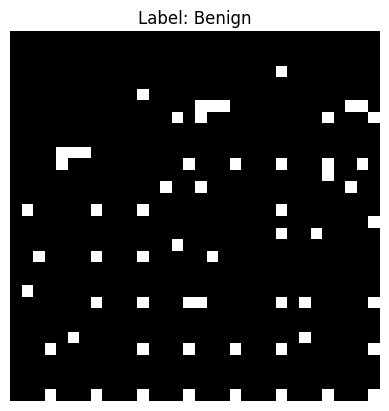

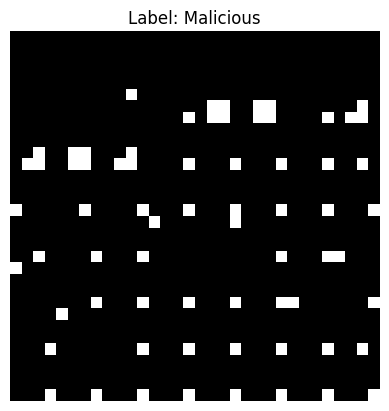

In [33]:
# plot a benign image
def plot_image(image, label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")
    plt.show()


benign_image = train_dataset[0][0]
plot_image(benign_image, "Benign")

malicious_image = train_dataset[-1][0]
plot_image(malicious_image, "Malicious")

In [34]:
model_savepath = f"../models/checkpoints/"

pathname_map = {
    'BinaryCNN': "bcnn",
    'BinaryCNN3': "bcnn3",
    'BinaryCNN2': "bcnn2"
}


benign_count = train_df_encoded["Label"].value_counts()[1]
malicious_count = train_df_encoded["Label"].value_counts().sum() - benign_count

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

# pos_weight = torch.tensor([7], dtype=torch.float32).to(device)

pos_weight

tensor([5.], device='cuda:0')

In [35]:
best_stats = {
    "bcnn" : {
        "cos": {
            "model": None,
            "history": None,
            "threshold": None,
        },
        "plateau": {
            "model": None,
            "history": None,
            "threshold": None
        }
    },
    "bcnn2" : {
        "cos": {
            "model": None,
            "history": None,
            "threshold": None
        },
        "plateau": {
            "model": None,
            "history": None,
            "threshold": None
        }
    },
    "bcnn3" : {
        "cos": {
            "model": None,
            "history": None,
            "threshold": None
        },
        "plateau": {
            "model": None,
            "history": None,
            "threshold": None
        }
    }
}


for model_class in [BinaryCNN3, BinaryCNN2, BinaryCNN]:
    model_name = model_class.__name__

    model_savepath_cosine = f"{model_savepath}{pathname_map[model_name]}_cosine_transformed.pth"
    model_savepath_plateau = f"{model_savepath}{pathname_map[model_name]}_plateau_transformed.pth"

    print(f"Training {model_name} with CosineAnnealingWarmRestarts")
    best_model_cos, history_cos, threshold_cos = train_model_cosine(model_class, criterion_logits, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=pos_weight, model_savepath=model_savepath_cosine, debug=False)
    best_stats[pathname_map[model_name]]["cos"]["model"] = best_model_cos
    best_stats[pathname_map[model_name]]["cos"]["history"] = history_cos
    best_stats[pathname_map[model_name]]["cos"]["threshold"] = threshold_cos

    print(f"Training {model_name} with ReduceLROnPlateau")
    best_model_plateau, history_plateau, threshold_plateau = train_model_reduceonplateau(model_class, criterion_logits, train_data_loader, val_data_loader, num_epochs=50, lr=1e-3, early_stop=10, device=device, weights=pos_weight, model_savepath=model_savepath_plateau, debug=False)
    best_stats[pathname_map[model_name]]["plateau"]["model"] = best_model_plateau
    best_stats[pathname_map[model_name]]["plateau"]["history"] = history_plateau
    best_stats[pathname_map[model_name]]["plateau"]["threshold"] = threshold_plateau
    print("\n\n")

Training BinaryCNN3 with CosineAnnealingWarmRestarts

Epoch 1/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:28<00:00, 26.20it/s]



Loss - Train: 0.0156, Val: 0.0135
Accuracy - Train: 0.8216, Val: 0.8198
Best Threshold: 0.85

Epoch 2/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:16<00:00, 45.79it/s]



Loss - Train: 0.0114, Val: 0.0120
Accuracy - Train: 0.8812, Val: 0.8279
Best Threshold: 0.85

Epoch 3/50
--------------------------------------------------


...


Loss - Train: 0.0083, Val: 0.0097
Accuracy - Train: 0.9085, Val: 0.8431
Best Threshold: 0.85

Epoch 19/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:23<00:00, 31.51it/s]



Loss - Train: 0.0082, Val: 0.0096
Accuracy - Train: 0.9088, Val: 0.8448
Best Threshold: 0.85

Epoch 20/50
--------------------------------------------------


Validation Batches: 100%|██████████| 750/750 [00:24<00:00, 30.48it/s]



Loss - Train: 0.0082, Val: 0.0099
Accuracy - Train: 0.9100, Val: 0.8435
Best Threshold: 0.85

Early stopping at epoch 20

Best model was from epoch 10 with validation loss 0.0094 and threshold 0.85





Model: bcnn
CosineAnnealingWarmRestarts


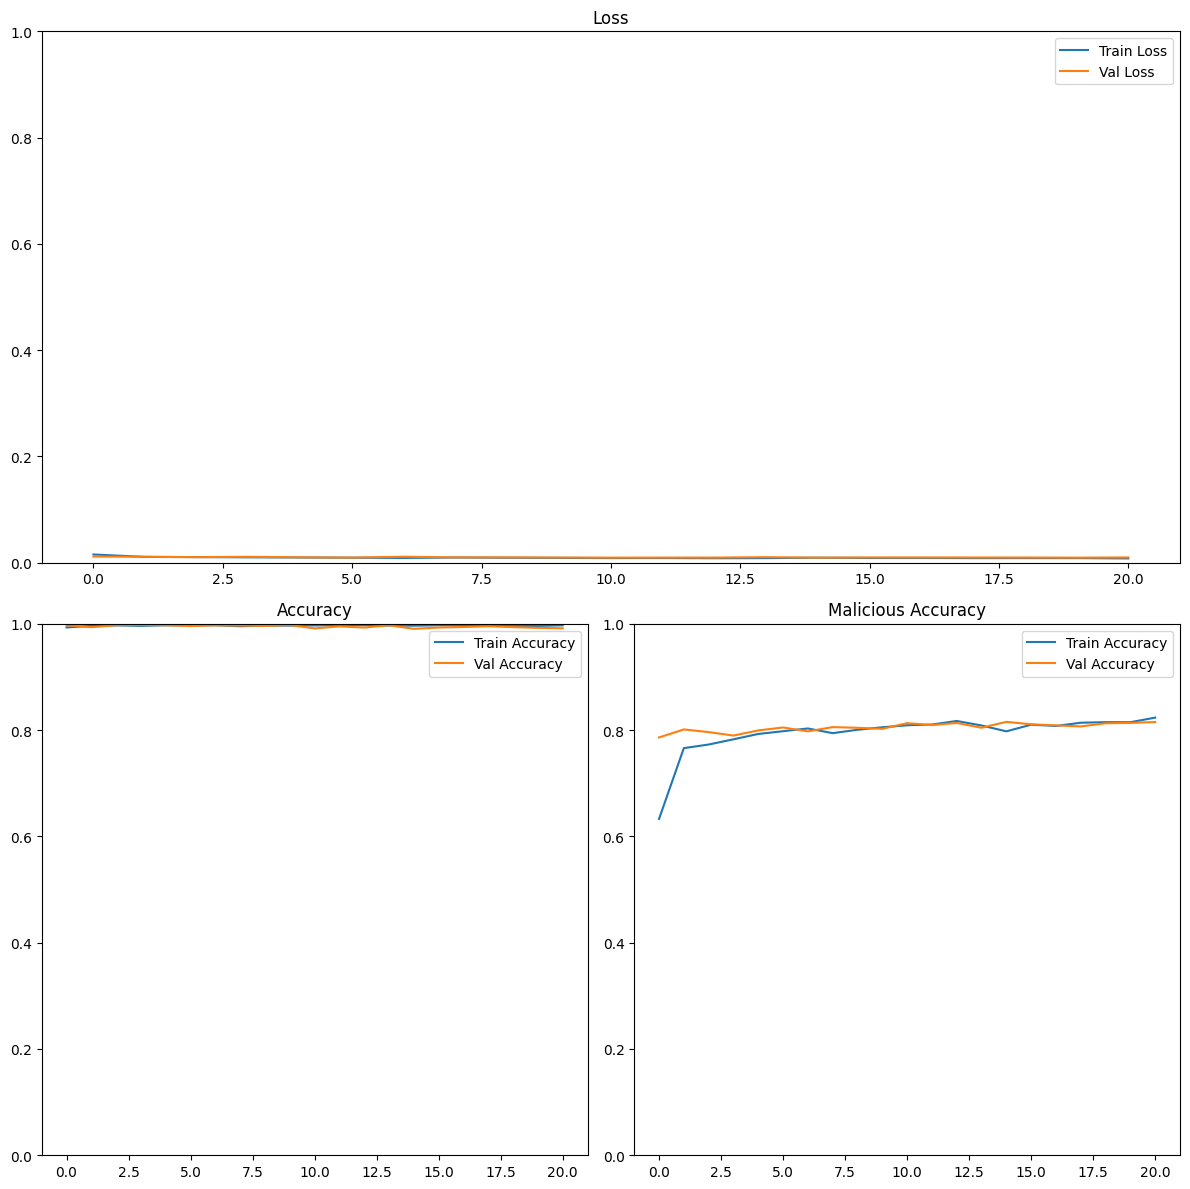

ReduceLROnPlateau


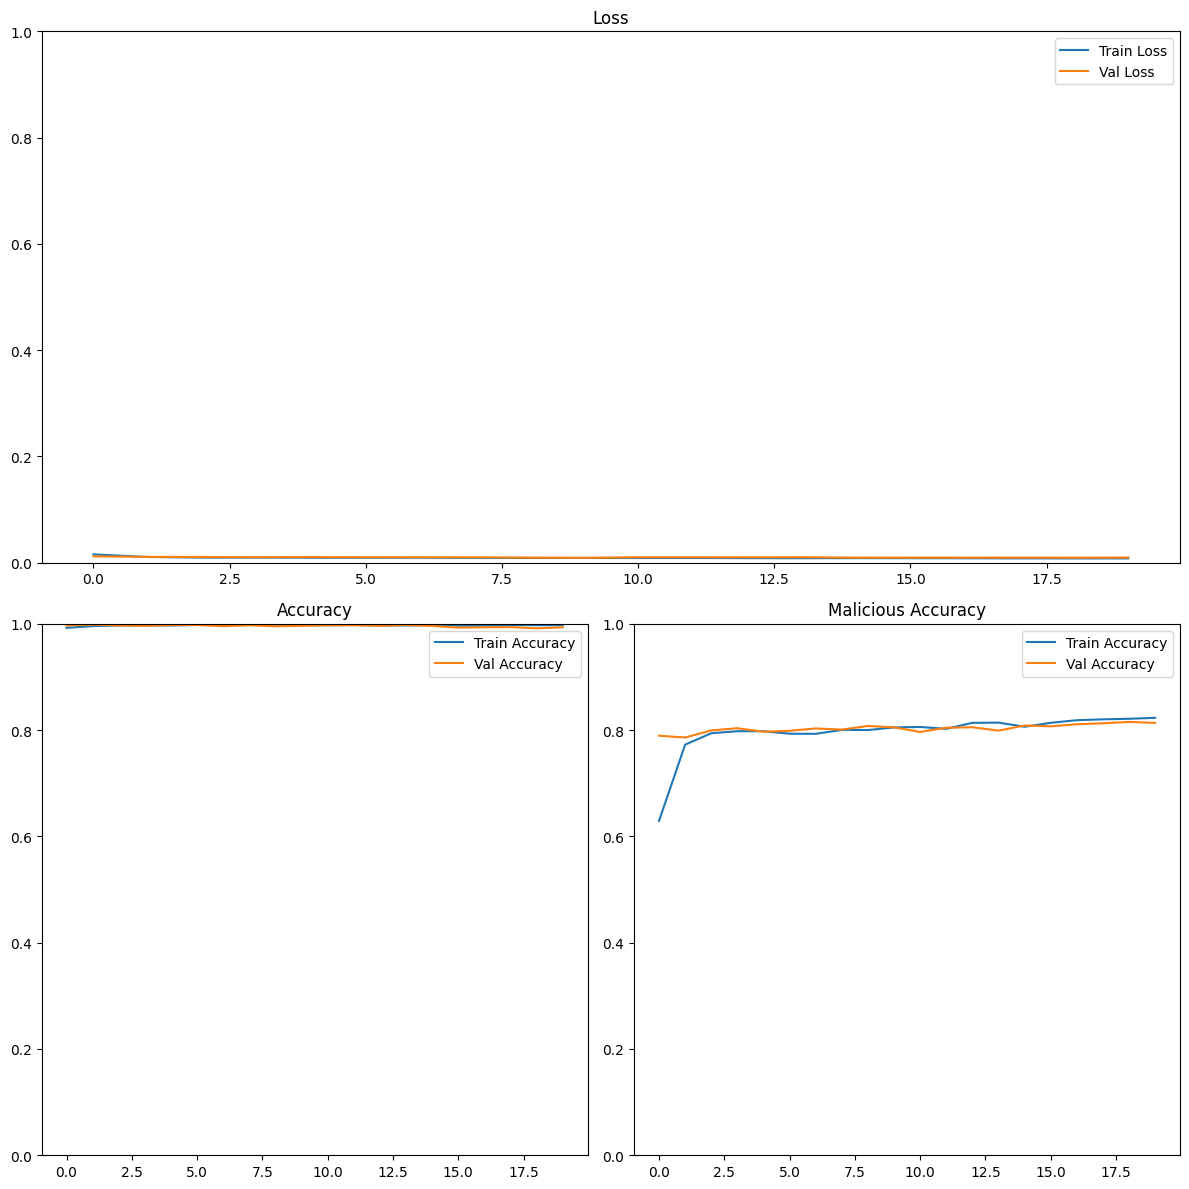




Model: bcnn2
CosineAnnealingWarmRestarts


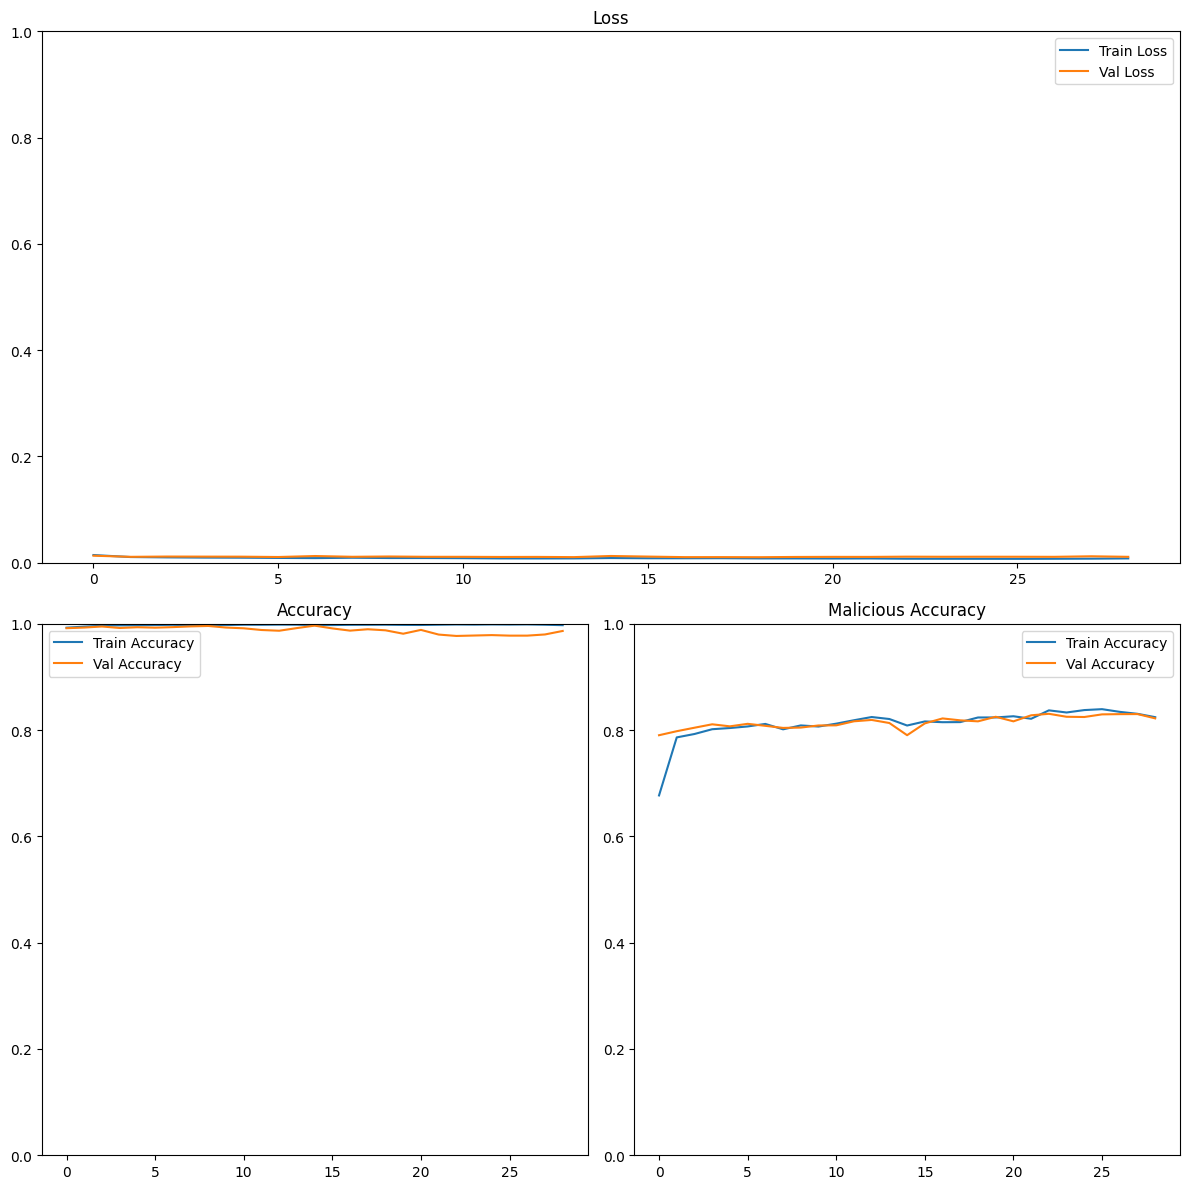

ReduceLROnPlateau


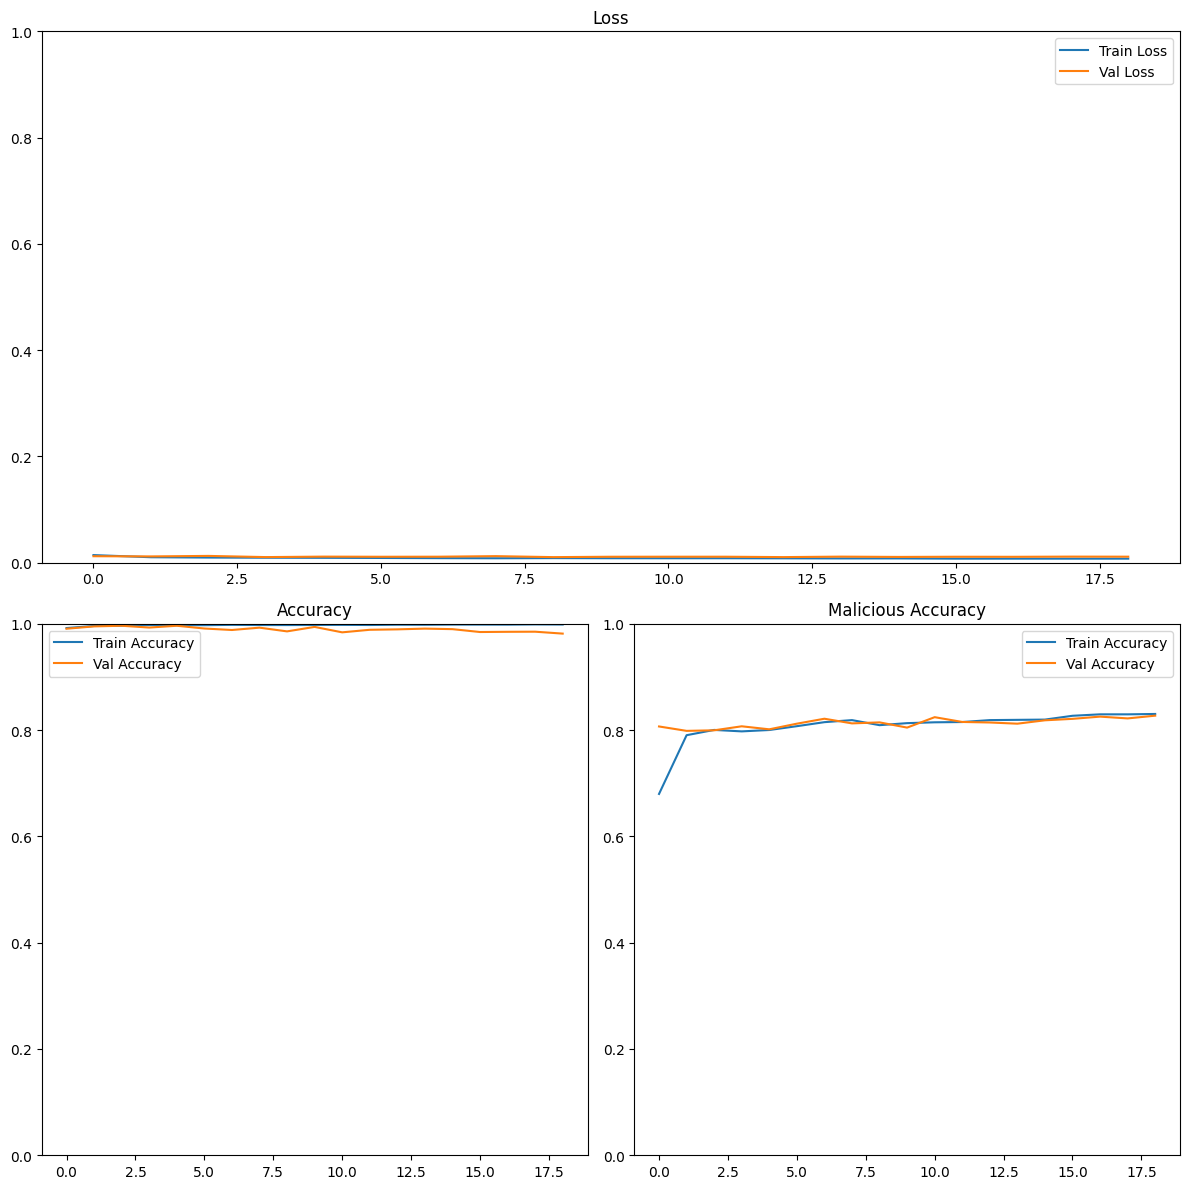




Model: bcnn3
CosineAnnealingWarmRestarts


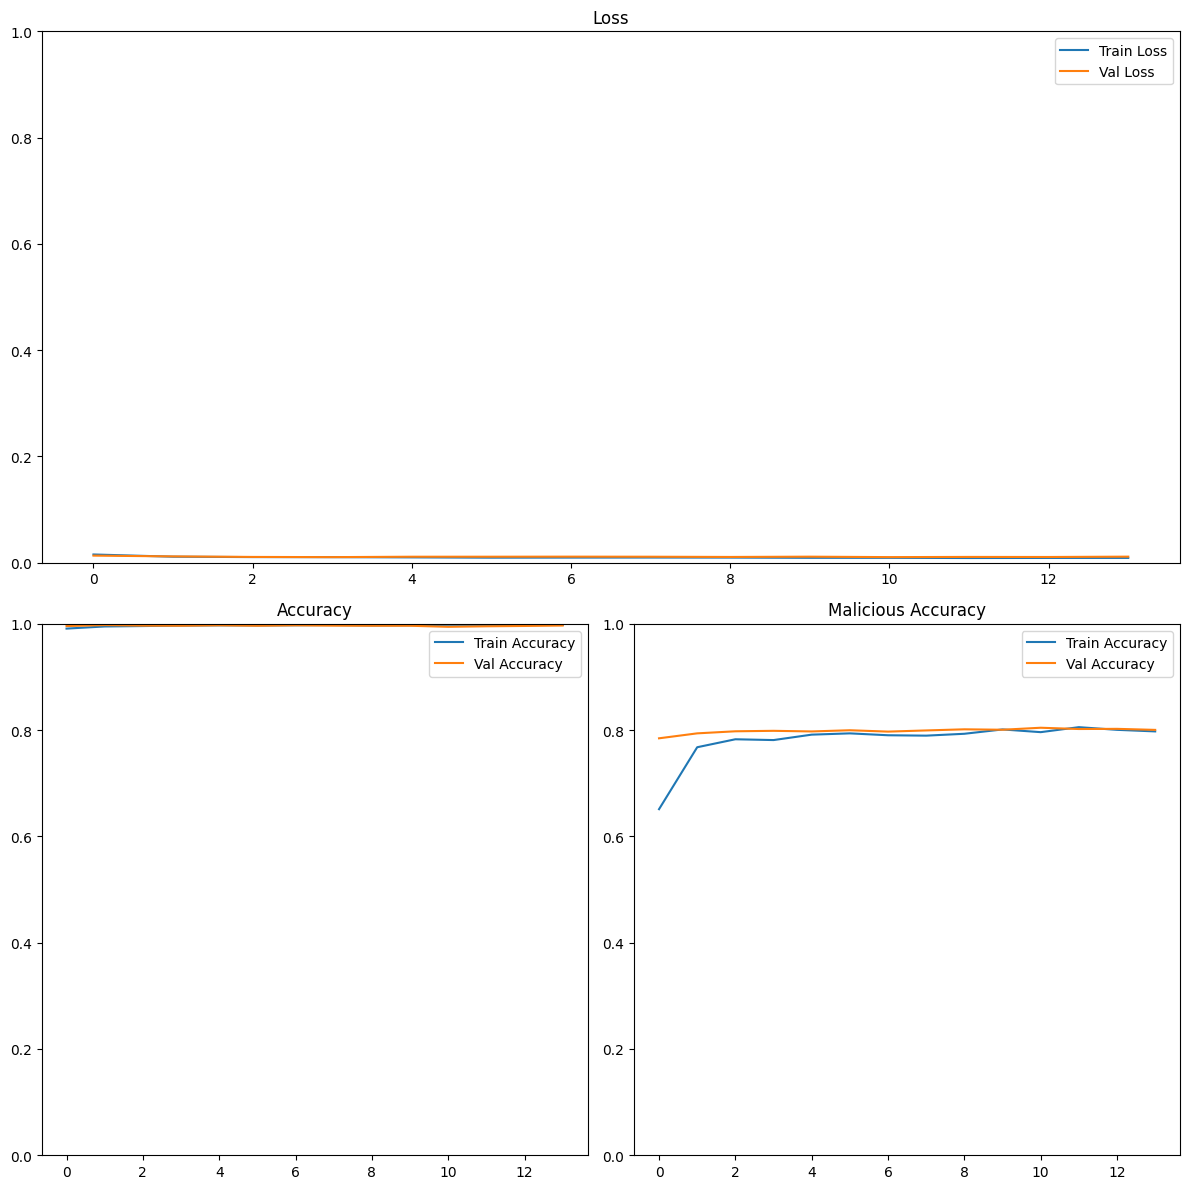

ReduceLROnPlateau


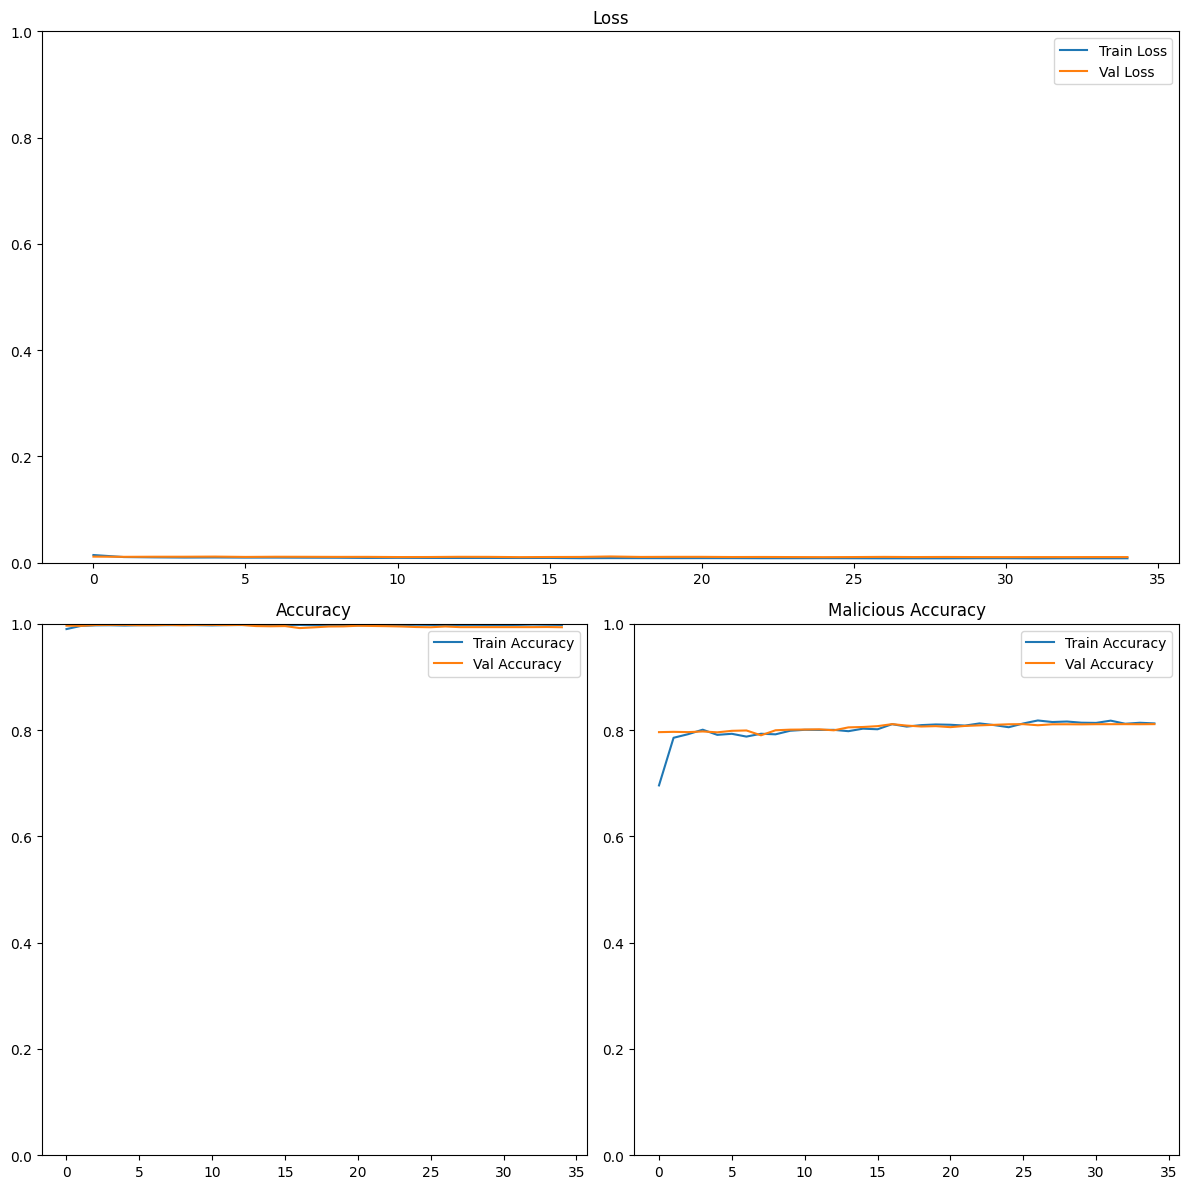

In [36]:
# plot metrics for each model
for model_name, model_stats in best_stats.items():
    print(f"Model: {model_name}")
    print("CosineAnnealingWarmRestarts")
    plot_metrics(model_stats["cos"]["history"])
    print("ReduceLROnPlateau")
    plot_metrics(model_stats["plateau"]["history"])
    print("\n\n")

In [37]:
test_data_encoded = test_df.copy()
test_data_encoded["Label"] = LE.transform(test_data_encoded["Label"])

In [38]:
test_dataset = CustomDataset(test_data_encoded, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [39]:
from sklearn.metrics import confusion_matrix

def test_model(model, test_dataset, device="cuda", threshold=0.5):
    
    preds = []
    true = []

    with torch.no_grad():
        model.eval()
        for i, (images, labels) in tqdm(enumerate(test_dataset), desc=f"Testing Batches"):
            images, labels = images.to(device), labels.float().to(device)

            outputs = model(images)
            preds.extend((torch.sigmoid(outputs) > threshold).flatten().detach().cpu().numpy())
            true.extend(labels.squeeze().detach().cpu().numpy())

    return true, preds

def test_metrics(true, preds):
    accuracy, precision, recall, f1 = calculate_metrics(true, preds)
    
    # confusion matrix
    cm = confusion_matrix(true, preds)

    # plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    plt.title("Confusion Matrix")

    plt.colorbar()

    # 1 is benign, 0 is malicious in predictions and labels

    
    plt.xticks([0, 1], ["Malicious", "Benign"])
    plt.yticks([0, 1], ["Malicious", "Benign"])


    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='red')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")



    plt.show()

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return accuracy, precision, recall, f1


In [40]:
# sample 10000 data points from test data with equal distribution of benign and malicious samples
test_data_sample = test_data_encoded.groupby("Label").sample(5000, random_state=42)

test_dataset_sample = CustomDataset(test_data_sample, f"{DATASET_DIR}/images", transform=val_transform)
test_data_loader_sample = DataLoader(test_dataset_sample, batch_size=BATCH_SIZE, shuffle=False)

Testing BinaryCNN with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:12, 20.20it/s]


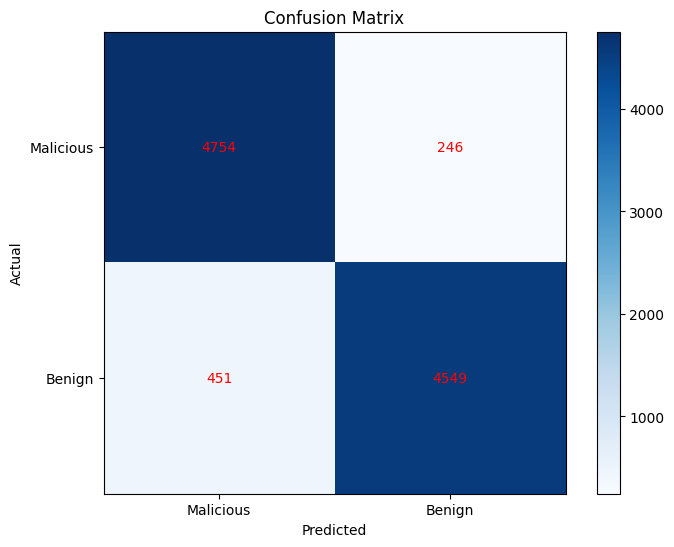

Accuracy: 0.9303
Precision: 0.9487
Recall: 0.9098
F1 Score: 0.9288



Testing BinaryCNN with ReduceLROnPlateau


Testing Batches: 250it [00:08, 28.37it/s]


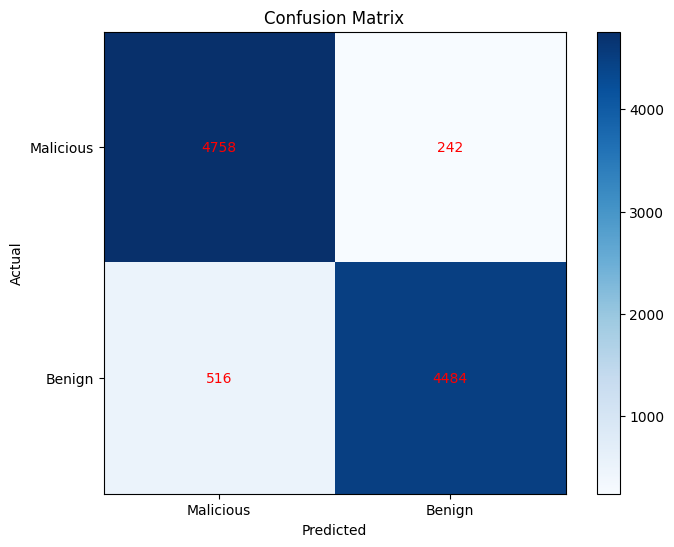

Accuracy: 0.9242
Precision: 0.9488
Recall: 0.8968
F1 Score: 0.9221



Testing BinaryCNN2 with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:08, 28.70it/s]


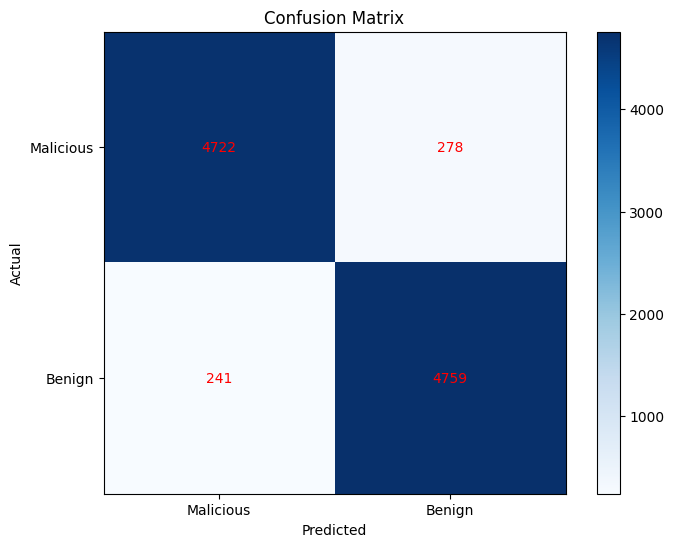

Accuracy: 0.9481
Precision: 0.9448
Recall: 0.9518
F1 Score: 0.9483



Testing BinaryCNN2 with ReduceLROnPlateau


Testing Batches: 250it [00:08, 28.49it/s]


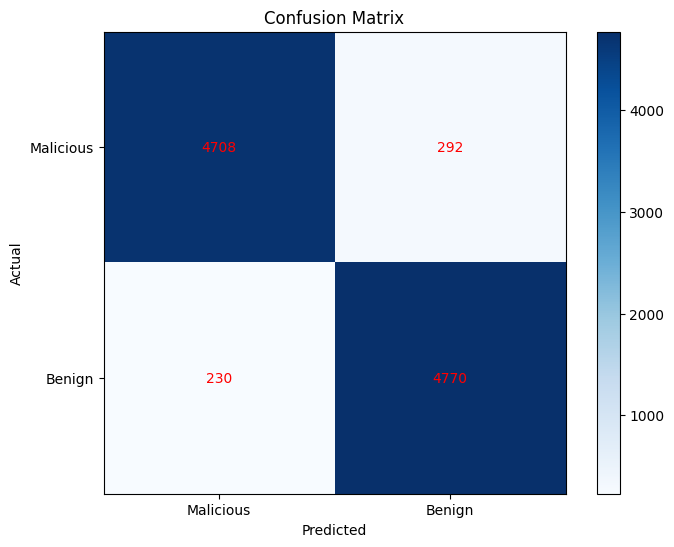

Accuracy: 0.9478
Precision: 0.9423
Recall: 0.9540
F1 Score: 0.9481



Testing BinaryCNN3 with CosineAnnealingWarmRestarts


Testing Batches: 250it [00:07, 31.93it/s]


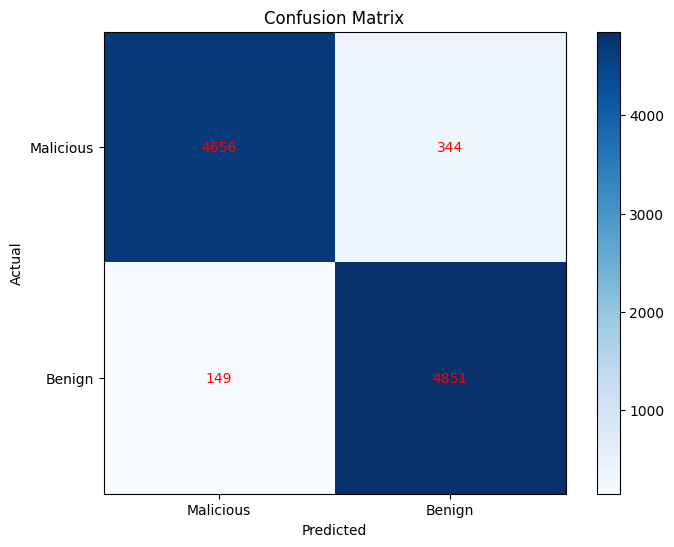

Accuracy: 0.9507
Precision: 0.9338
Recall: 0.9702
F1 Score: 0.9516



Testing BinaryCNN3 with ReduceLROnPlateau


Testing Batches: 250it [00:07, 31.55it/s]


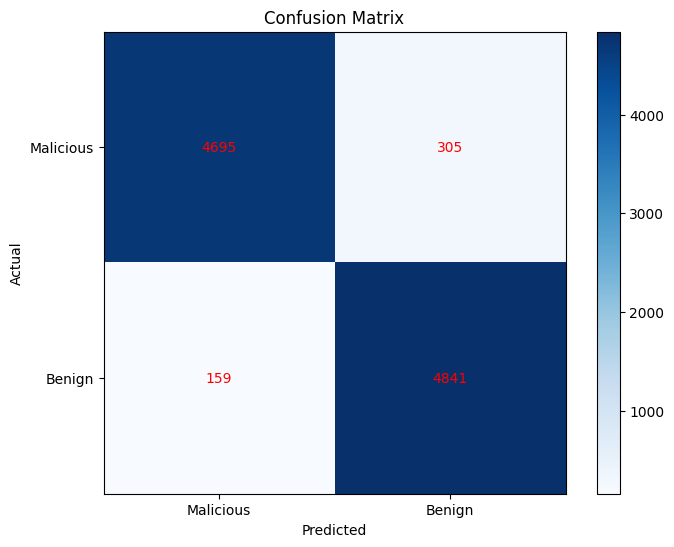

Accuracy: 0.9536
Precision: 0.9407
Recall: 0.9682
F1 Score: 0.9543





In [41]:
# model = BinaryCNN2().to(device)
# model.load_state_dict(torch.load(model_savepath, weights_only=True))


# test each model with the test data
# load model from checkpoint
# calculate metrics for each model

for model_class in [BinaryCNN, BinaryCNN2, BinaryCNN3]:
    model_name = model_class.__name__
    print(f"Testing {model_name} with CosineAnnealingWarmRestarts")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["cos"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device, threshold=best_stats[pathname_map[model_name]]["cos"]["threshold"])
    test_metrics(true, preds)
    print("\n\n")

    print(f"Testing {model_name} with ReduceLROnPlateau")
    model = model_class().to(device)
    model.load_state_dict(best_stats[pathname_map[model_name]]["plateau"]["model"])
    true, preds = test_model(model, test_data_loader_sample, device, threshold=best_stats[pathname_map[model_name]]["plateau"]["threshold"])
    test_metrics(true, preds)
    print("\n\n")


In [42]:
# test_true, test_preds = test_model(model, test_data_loader_sample, device=device, threshold=0.5)
# test_metrics(test_true, test_preds)

In [43]:
# test_data_sample.loc[762771]

In [44]:
# benign_predictions = []
# malicious_predictions = []

# for i, (images, labels) in tqdm(enumerate(test_data_loader_sample), desc="Testing Batches"):
#     images, labels = images.to(device), labels.float().to(device)

#     outputs = model(images)
#     probs = torch.sigmoid(outputs).flatten().detach().cpu().numpy()
    
#     for j in range(len(probs)):
#         if labels[j] == 1:
#             benign_predictions.append(probs[j])
#         else:
#             malicious_predictions.append(probs[j])


In [45]:
# malicious_predictions = np.array(malicious_predictions)
# benign_predictions = np.array(benign_predictions)

# # plot points
# plt.figure(figsize=(10, 6))
# plt.scatter(range(len(malicious_predictions)), malicious_predictions, label="Malicious", alpha=0.5)
# plt.scatter(range(len(benign_predictions)), benign_predictions, label="Benign", alpha=0.5)
# plt.axhline(y=best_threshold, color='r', linestyle='--', label="Threshold")
# plt.xlabel("Sample Index")
# plt.ylabel("Prediction Probability")
# plt.title("Prediction Probabilities")
# plt.legend()
# plt.show()

In [46]:
# malicious_predictions.max(), malicious_predictions.min(), benign_predictions.max(), benign_predictions.min()

In [47]:
# best_threshold = 0.5